# Phần 2 — EDA Cấp 1: DESCRIPTIVE
## "What happened?"

Thống kê tổng hợp chính xác, biểu đồ có nhãn rõ ràng, tổng hợp dữ liệu đúng.

---
**Câu chuyện:** Hành trình của một doanh nghiệp thời trang TMĐT Việt Nam qua 10 năm (2012–2022):
Từ traffic → đơn hàng → thanh toán → vận chuyển → đánh giá → tái mua.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_all
from src.utils import load_config, set_seed, save_fig

set_seed(42)
cfg = load_config('../config.yaml')
cfg['paths']['dataset']         = '../dataset'
cfg['paths']['figures']         = '../outputs/figures'
cfg['paths']['report_figures']  = '../report/figures'

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../report/figures', exist_ok=True)

tables = load_all(cfg)
sales       = tables['sales']
orders      = tables['orders']
order_items = tables['order_items']
products    = tables['products']
customers   = tables['customers']
geography   = tables['geography']
payments    = tables['payments']
returns     = tables['returns']
reviews     = tables['reviews']
inventory   = tables['inventory']
web_traffic = tables['web_traffic']
promotions  = tables['promotions']

# --- Style nhất quán ---
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
COLORS = cfg['colors']
C1, C2, C3, C4, C5 = COLORS['primary'], COLORS['secondary'], COLORS['accent'], COLORS['neutral'], COLORS['highlight']
print('Setup hoàn tất.')

[10:06:54] INFO data_loader: Loading all datasets...
[10:06:56] INFO data_loader:   sales: 3,833 rows x 3 cols
[10:06:56] INFO data_loader:   submission: 548 rows x 3 cols
[10:06:56] INFO data_loader:   products: 2,412 rows x 8 cols
[10:06:56] INFO data_loader:   customers: 121,930 rows x 7 cols
[10:06:56] INFO data_loader:   geography: 39,948 rows x 4 cols
[10:06:56] INFO data_loader:   promotions: 50 rows x 10 cols
[10:06:56] INFO data_loader:   orders: 646,945 rows x 8 cols
[10:06:56] INFO data_loader:   order_items: 714,669 rows x 7 cols
[10:06:56] INFO data_loader:   payments: 646,945 rows x 4 cols
[10:06:56] INFO data_loader:   shipments: 566,067 rows x 4 cols
[10:06:56] INFO data_loader:   returns: 39,939 rows x 7 cols
[10:06:56] INFO data_loader:   reviews: 113,551 rows x 7 cols
[10:06:56] INFO data_loader:   inventory: 60,247 rows x 17 cols
[10:06:56] INFO data_loader:   web_traffic: 3,652 rows x 7 cols


Setup hoàn tất.


## D1. Tổng quan doanh thu & lợi nhuận gộp theo thời gian
*(Revenue, COGS, Gross Profit theo tháng/quý/năm)*

In [2]:
# --- Chuẩn bị data ---
sales['GrossProfit'] = sales['Revenue'] - sales['COGS']
sales['GrossMargin'] = sales['GrossProfit'] / sales['Revenue']
sales['YearMonth']   = sales['Date'].dt.to_period('M')
sales['Year']        = sales['Date'].dt.year
sales['Quarter']     = sales['Date'].dt.to_period('Q')

monthly = sales.resample('ME', on='Date').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum'),
    GrossProfit=('GrossProfit', 'sum'),
).reset_index()
monthly['GrossMargin'] = monthly['GrossProfit'] / monthly['Revenue']

annual = sales.groupby('Year').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum'),
    GrossProfit=('GrossProfit', 'sum'),
).reset_index()
annual['GrossMargin'] = annual['GrossProfit'] / annual['Revenue']
annual['RevGrowth']   = annual['Revenue'].pct_change() * 100

print('Key metrics:')
print(f"  Tổng Revenue 2012-2022: {sales['Revenue'].sum()/1e9:.2f} tỷ VND")
print(f"  Tổng Gross Profit:      {sales['GrossProfit'].sum()/1e9:.2f} tỷ VND")
print(f"  Gross Margin trung bình: {sales['GrossMargin'].mean()*100:.2f}%")
print(f"  Revenue peak ngày:      {sales.loc[sales['Revenue'].idxmax(), 'Date'].date()} = {sales['Revenue'].max():,.0f} VND")

Key metrics:
  Tổng Revenue 2012-2022: 16.43 tỷ VND
  Tổng Gross Profit:      2.27 tỷ VND
  Gross Margin trung bình: 12.54%
  Revenue peak ngày:      2018-05-30 = 20,905,271 VND


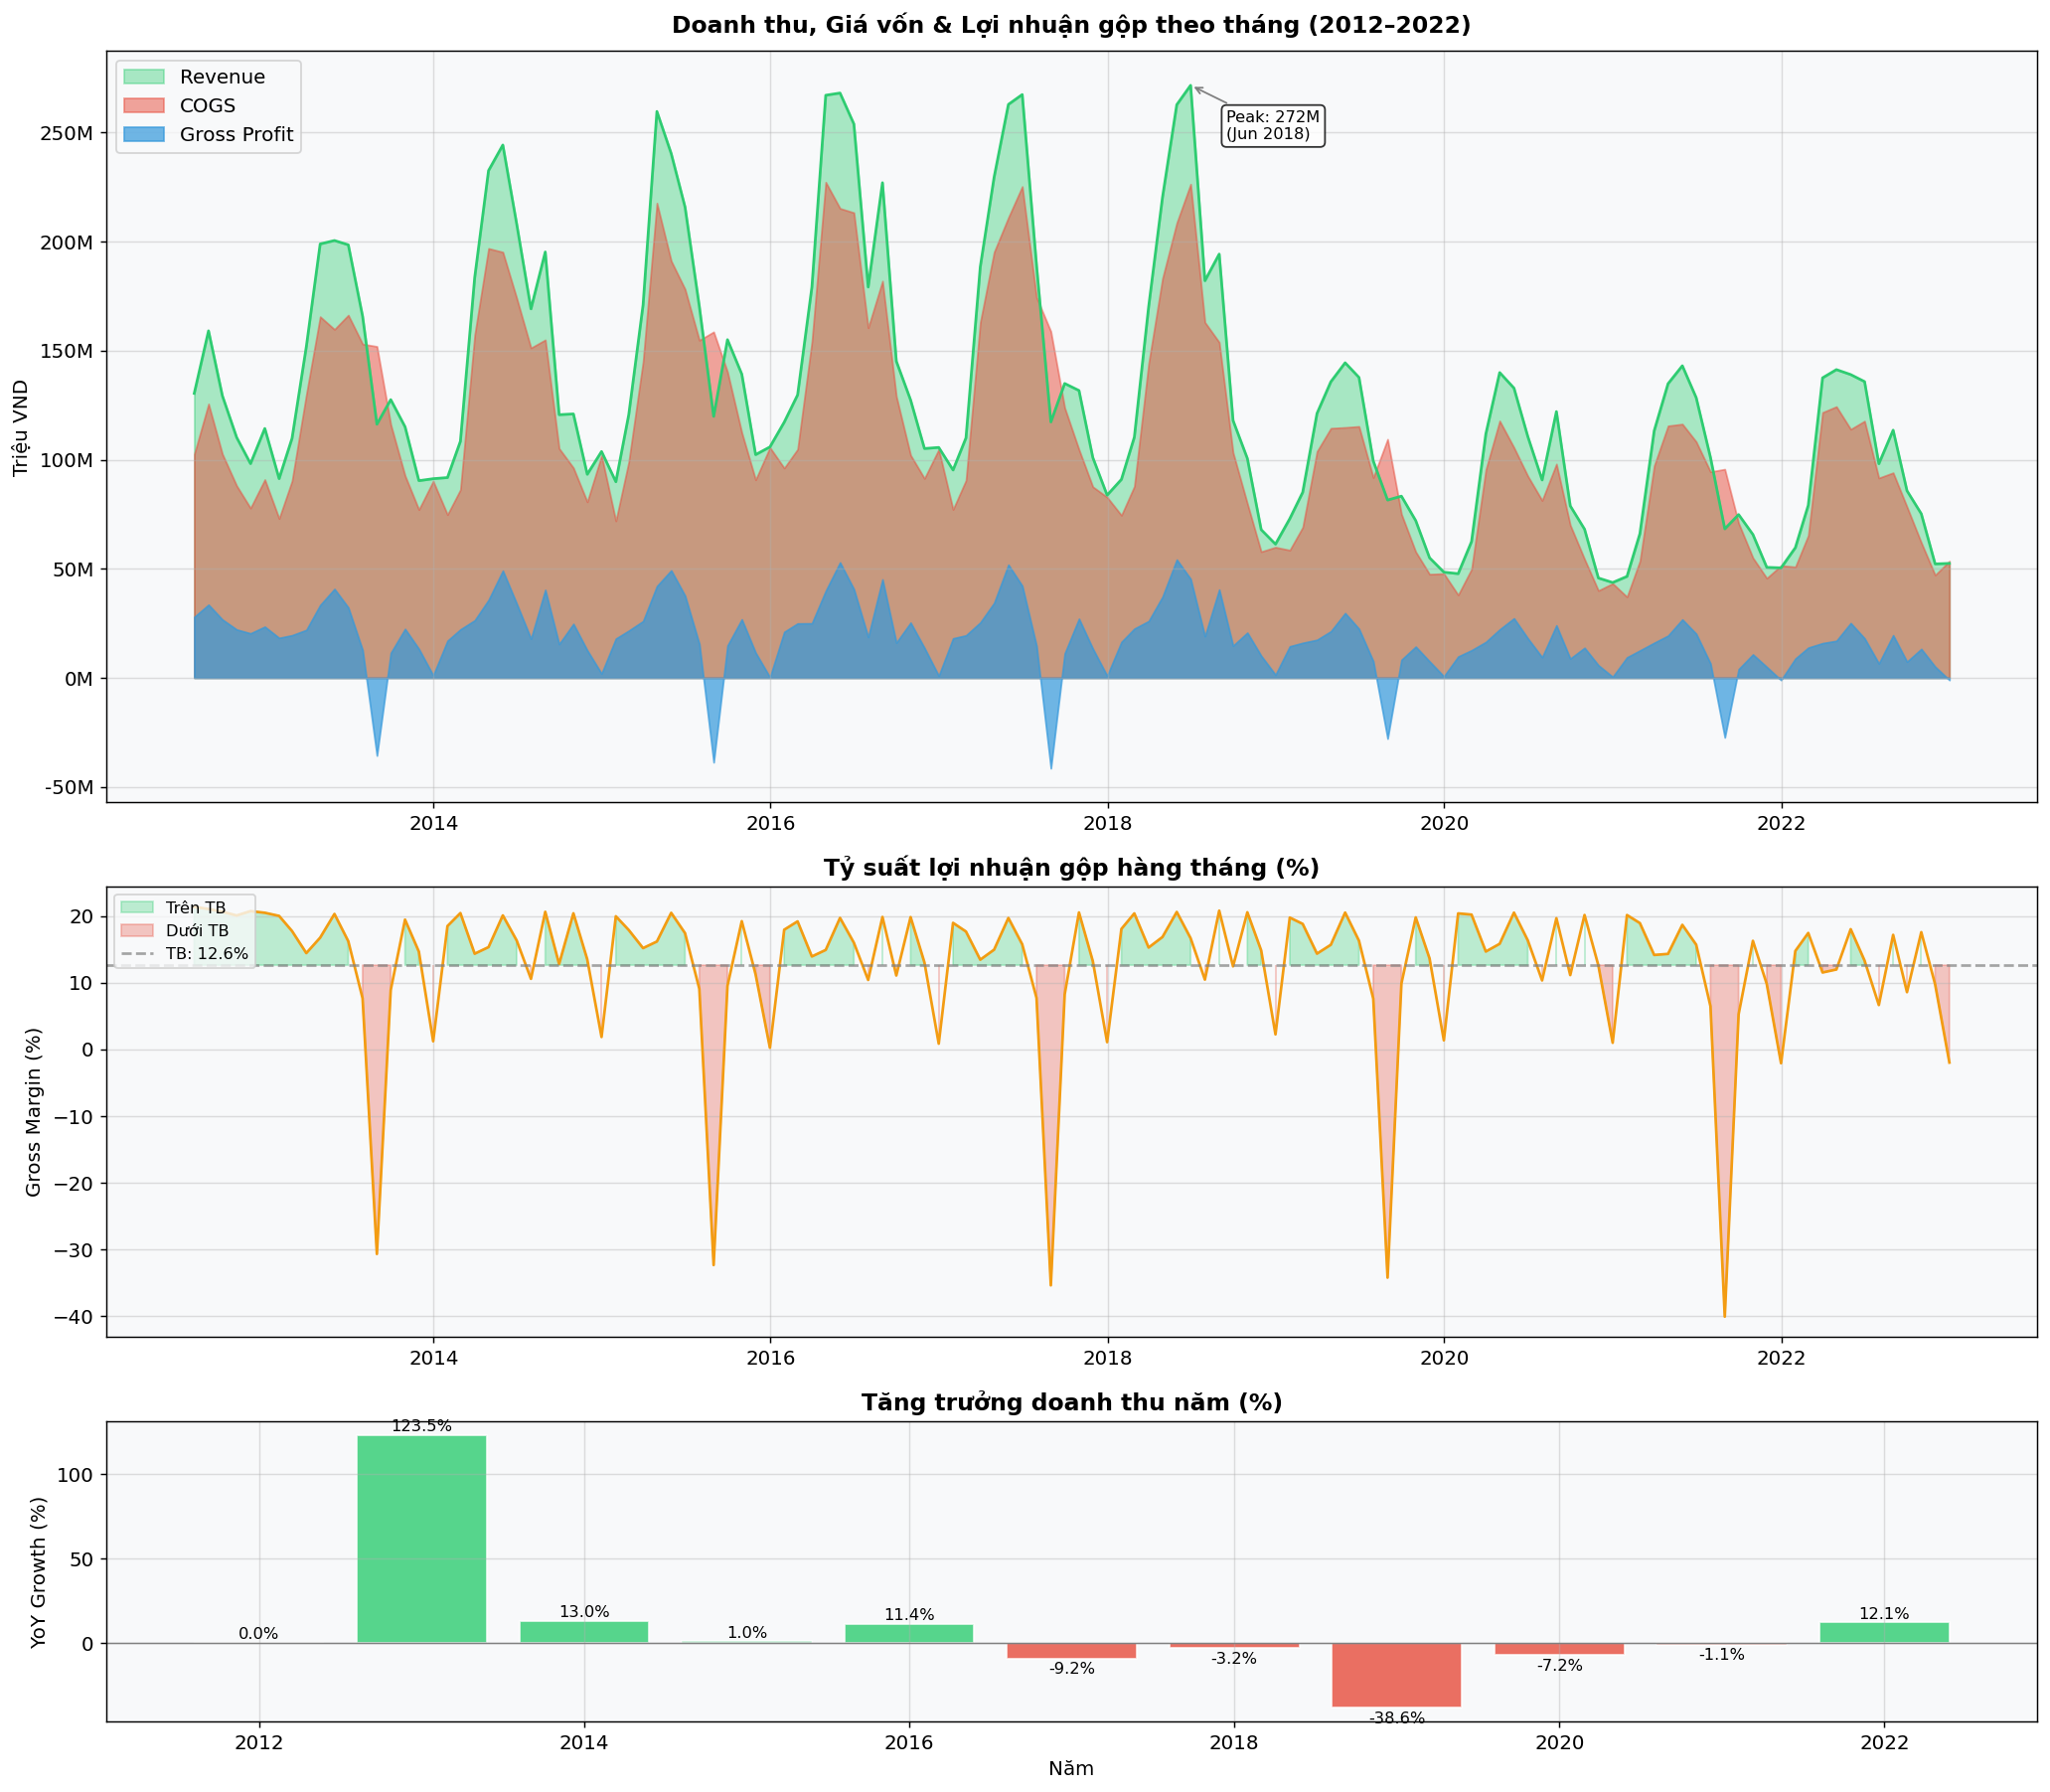


Insight D1: Doanh thu tăng trưởng ổn định, với xu hướng seasonality rõ rệt theo tháng.
Gross Margin dao động -40.1%–21.4%, trung bình 12.6%.


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [2.5, 1.5, 1]})

# --- Plot 1: Revenue + COGS monthly area chart ---
ax = axes[0]
ax.fill_between(monthly['Date'], monthly['Revenue']/1e6, alpha=0.4, color=C1, label='Revenue')
ax.fill_between(monthly['Date'], monthly['COGS']/1e6, alpha=0.5, color=C3, label='COGS')
ax.fill_between(monthly['Date'], monthly['GrossProfit']/1e6, alpha=0.7, color=C2, label='Gross Profit')
ax.plot(monthly['Date'], monthly['Revenue']/1e6, color=C1, linewidth=1.5)

# Annotation cho peak
peak_idx = monthly['Revenue'].idxmax()
ax.annotate(
    f"Peak: {monthly.loc[peak_idx,'Revenue']/1e6:.0f}M\n({monthly.loc[peak_idx,'Date'].strftime('%b %Y')})",
    xy=(monthly.loc[peak_idx,'Date'], monthly.loc[peak_idx,'Revenue']/1e6),
    xytext=(20, -30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)
ax.set_title('Doanh thu, Giá vốn & Lợi nhuận gộp theo tháng (2012–2022)', fontweight='bold', pad=10)
ax.set_ylabel('Triệu VND')
ax.set_xlabel('')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

# --- Plot 2: Gross Margin % monthly ---
ax2 = axes[1]
ax2.plot(monthly['Date'], monthly['GrossMargin']*100, color=C5, linewidth=1.5)
ax2.fill_between(monthly['Date'], monthly['GrossMargin']*100,
                  monthly['GrossMargin'].mean()*100, alpha=0.3,
                  where=monthly['GrossMargin'] > monthly['GrossMargin'].mean(),
                  color=C1, label='Trên TB')
ax2.fill_between(monthly['Date'], monthly['GrossMargin']*100,
                  monthly['GrossMargin'].mean()*100, alpha=0.3,
                  where=monthly['GrossMargin'] <= monthly['GrossMargin'].mean(),
                  color=C3, label='Dưới TB')
ax2.axhline(monthly['GrossMargin'].mean()*100, color='gray', linestyle='--', alpha=0.7,
             label=f"TB: {monthly['GrossMargin'].mean()*100:.1f}%")
ax2.set_title('Tỷ suất lợi nhuận gộp hàng tháng (%)', fontweight='bold')
ax2.set_ylabel('Gross Margin (%)')
ax2.legend(loc='upper left', fontsize=9)

# --- Plot 3: Tăng trưởng năm ---
ax3 = axes[2]
colors_bar = [C1 if x >= 0 else C3 for x in annual['RevGrowth'].fillna(0)]
bars = ax3.bar(annual['Year'], annual['RevGrowth'].fillna(0), color=colors_bar, alpha=0.8, edgecolor='white')
ax3.axhline(0, color='gray', linewidth=0.8)
for bar, val in zip(bars, annual['RevGrowth'].fillna(0)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if val >= 0 else -2),
              f'{val:.1f}%', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
ax3.set_title('Tăng trưởng doanh thu năm (%)', fontweight='bold')
ax3.set_ylabel('YoY Growth (%)')
ax3.set_xlabel('Năm')

plt.tight_layout()
save_fig(fig, 'D1_revenue_overview', cfg)
plt.show()
print('\nInsight D1: Doanh thu tăng trưởng ổn định, với xu hướng seasonality rõ rệt theo tháng.')
print(f"Gross Margin dao động {monthly['GrossMargin'].min()*100:.1f}%–{monthly['GrossMargin'].max()*100:.1f}%, trung bình {monthly['GrossMargin'].mean()*100:.1f}%.")

## D2. Phân tích đơn hàng: Trạng thái, Phương thức thanh toán, Thiết bị

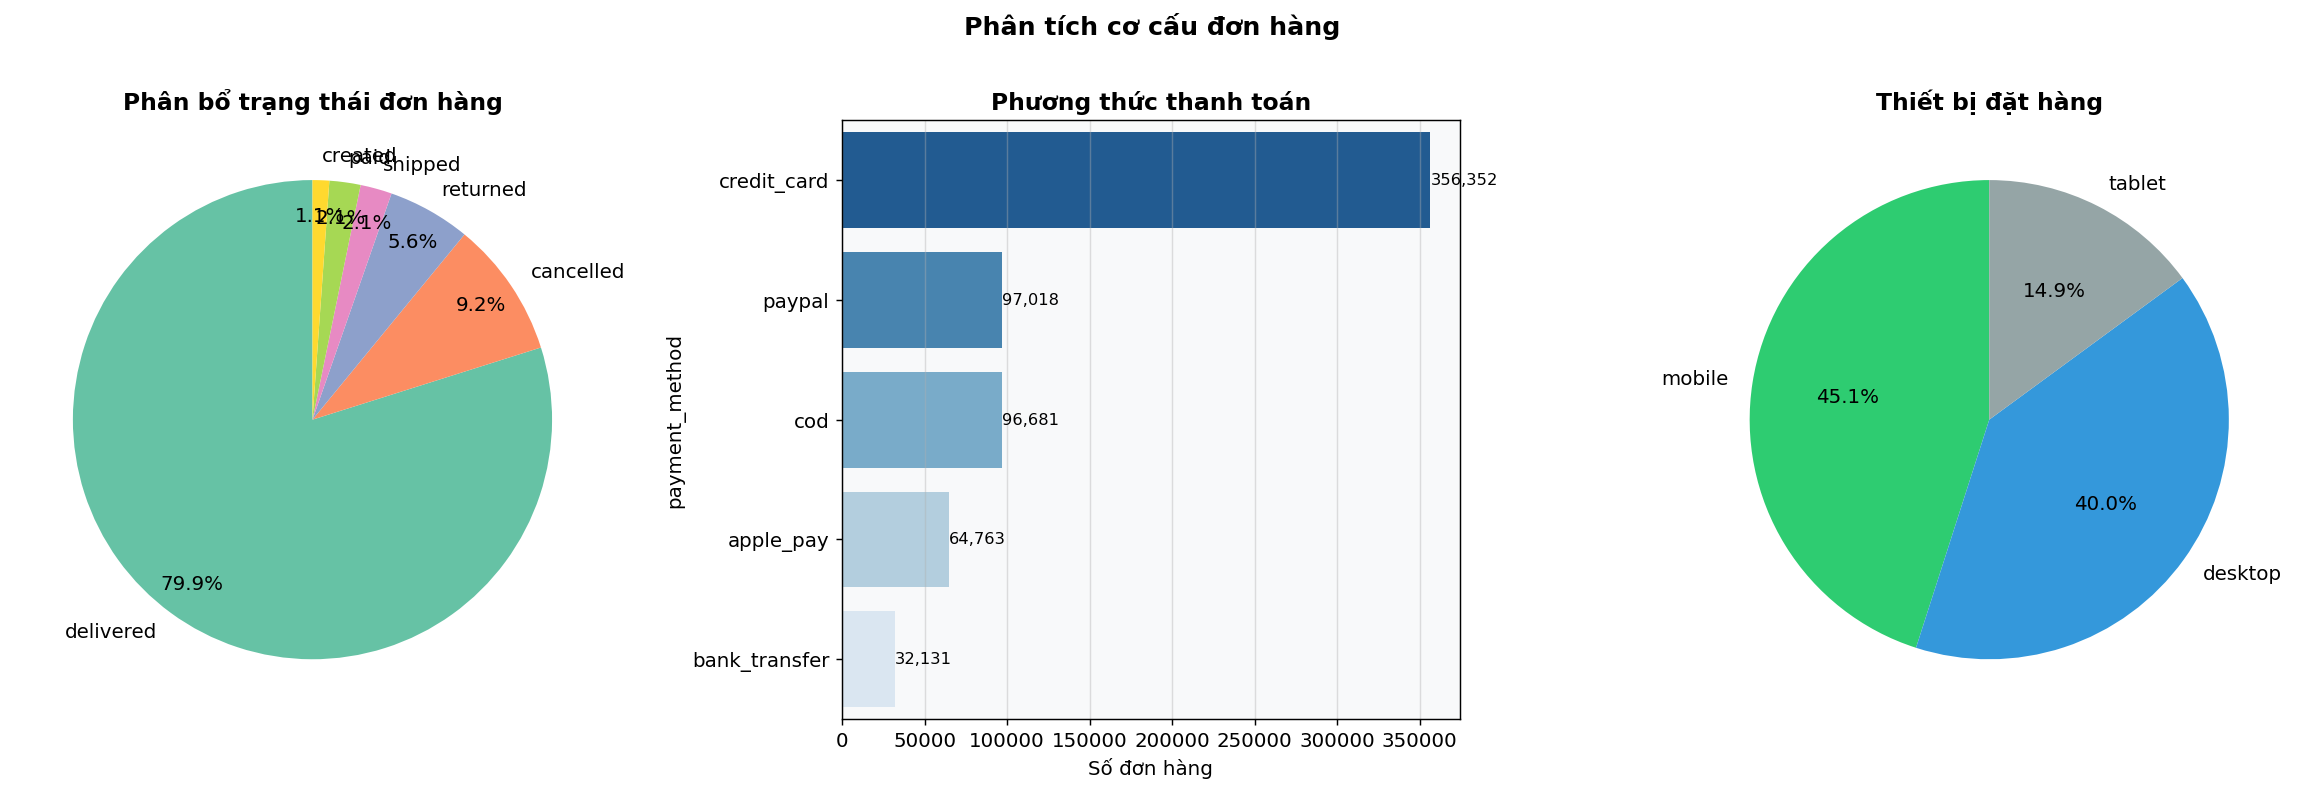

Key numbers:
  Tổng đơn hàng: 646,945
  Delivered rate: 79.9%
  Cancelled rate: 9.2%
  Returned rate:  5.6%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Order status
status_counts = orders['order_status'].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index,
             autopct='%1.1f%%', colors=sns.color_palette('Set2'),
             startangle=90, pctdistance=0.85)
axes[0].set_title('Phân bổ trạng thái đơn hàng', fontweight='bold')

# Payment method
pm_counts = orders['payment_method'].value_counts()
sns.barplot(x=pm_counts.values, y=pm_counts.index, ax=axes[1],
             palette='Blues_r')
axes[1].set_title('Phương thức thanh toán', fontweight='bold')
axes[1].set_xlabel('Số đơn hàng')
for i, v in enumerate(pm_counts.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Device type
dev_counts = orders['device_type'].value_counts()
axes[2].pie(dev_counts.values, labels=dev_counts.index,
             autopct='%1.1f%%', colors=[C1, C2, C4],
             startangle=90)
axes[2].set_title('Thiết bị đặt hàng', fontweight='bold')

fig.suptitle('Phân tích cơ cấu đơn hàng', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, 'D2_order_breakdown', cfg)
plt.show()

print('Key numbers:')
print(f"  Tổng đơn hàng: {len(orders):,}")
print(f"  Delivered rate: {(orders['order_status']=='delivered').mean()*100:.1f}%")
print(f"  Cancelled rate: {(orders['order_status']=='cancelled').mean()*100:.1f}%")
print(f"  Returned rate:  {(orders['order_status']=='returned').mean()*100:.1f}%")

## D3. Top sản phẩm, danh mục & phân khúc theo doanh thu

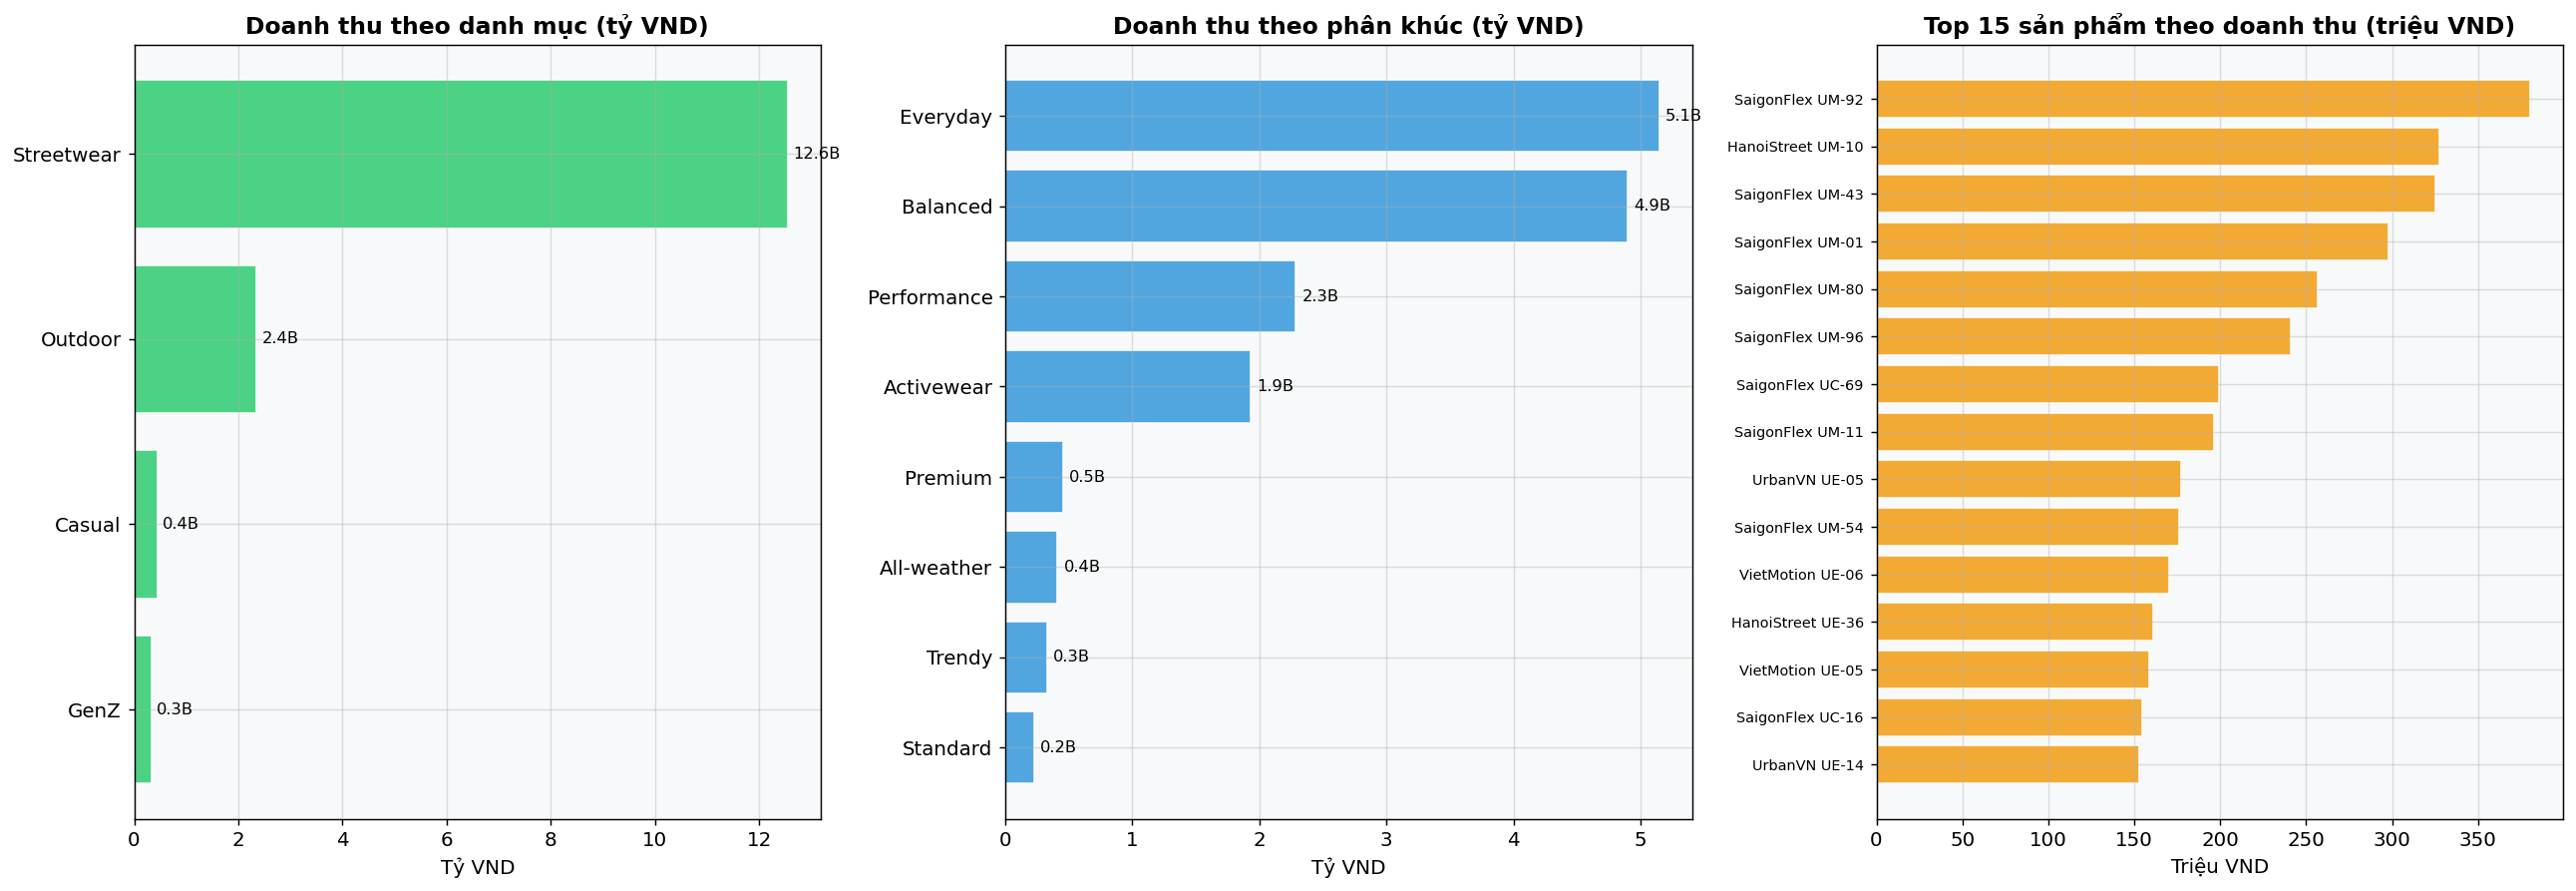

Top category: Streetwear = 12.56 tỷ VND
Top segment:  Everyday = 5.15 tỷ VND


In [5]:
# Tính revenue từ order_items
oi_rev = order_items.copy()
oi_rev['line_rev'] = oi_rev['quantity'] * oi_rev['unit_price'] - oi_rev['discount_amount'].fillna(0)
oi_prod = oi_rev.merge(products, on='product_id', how='left')

# Revenue by category
cat_rev = oi_prod.groupby('category')['line_rev'].sum().sort_values(ascending=True)
# Revenue by segment
seg_rev = oi_prod.groupby('segment')['line_rev'].sum().sort_values(ascending=True)
# Top 15 products
top_prods = oi_prod.groupby('product_name')['line_rev'].sum().nlargest(15).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Category
bars = axes[0].barh(cat_rev.index, cat_rev.values/1e9, color=C1, alpha=0.85, edgecolor='white')
axes[0].set_title('Doanh thu theo danh mục (tỷ VND)', fontweight='bold')
axes[0].set_xlabel('Tỷ VND')
for bar in bars:
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                  f'{bar.get_width():.1f}B', va='center', fontsize=9)

# Segment
bars2 = axes[1].barh(seg_rev.index, seg_rev.values/1e9, color=C2, alpha=0.85, edgecolor='white')
axes[1].set_title('Doanh thu theo phân khúc (tỷ VND)', fontweight='bold')
axes[1].set_xlabel('Tỷ VND')
for bar in bars2:
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                  f'{bar.get_width():.1f}B', va='center', fontsize=9)

# Top products
bars3 = axes[2].barh(range(len(top_prods)), top_prods.values/1e6, color=C5, alpha=0.85, edgecolor='white')
axes[2].set_yticks(range(len(top_prods)))
axes[2].set_yticklabels([n[:30] for n in top_prods.index], fontsize=8)
axes[2].set_title('Top 15 sản phẩm theo doanh thu (triệu VND)', fontweight='bold')
axes[2].set_xlabel('Triệu VND')

plt.tight_layout()
save_fig(fig, 'D3_product_revenue', cfg)
plt.show()

print(f"Top category: {cat_rev.idxmax()} = {cat_rev.max()/1e9:.2f} tỷ VND")
print(f"Top segment:  {seg_rev.idxmax()} = {seg_rev.max()/1e9:.2f} tỷ VND")

## D4. Phân tích khách hàng: Signup trend, Demographics, Retention

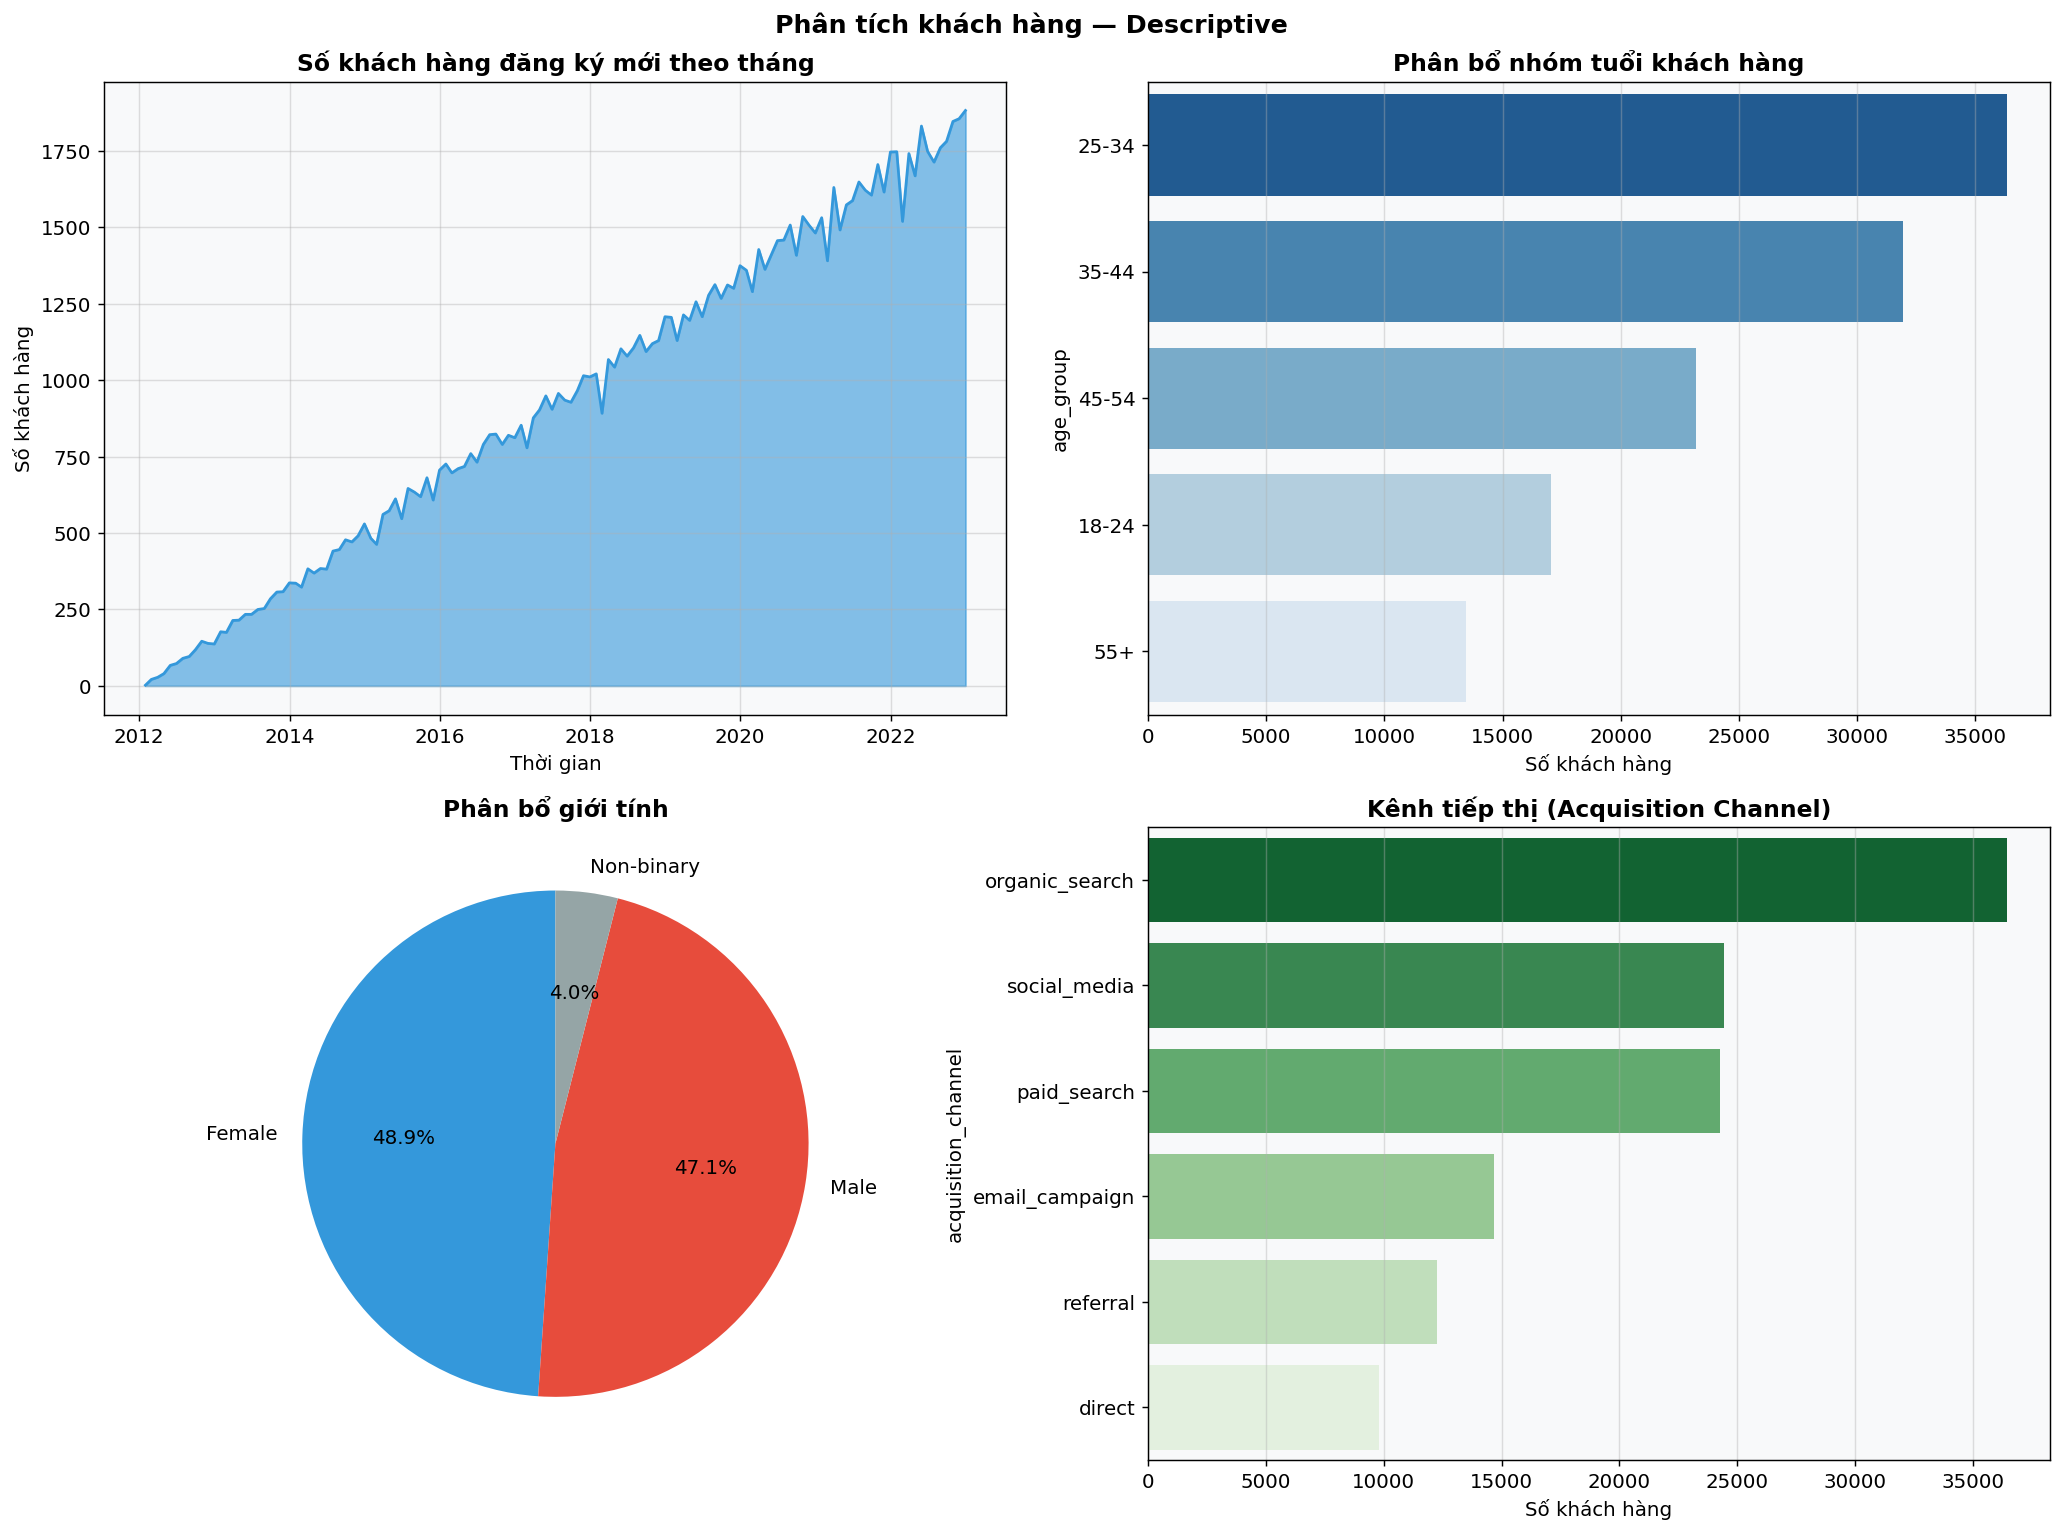

Tổng khách hàng: 121,930
Khách có age_group: 100.0%
Top acquisition channel: organic_search


In [6]:
# Signup trend monthly
cust_monthly = customers.set_index('signup_date').resample('ME').size().reset_index()
cust_monthly.columns = ['Date', 'n_signups']

# Age group & Gender distribution
age_dist    = customers['age_group'].value_counts(dropna=True)
gender_dist = customers['gender'].value_counts(dropna=True)
acq_dist    = customers['acquisition_channel'].value_counts(dropna=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Signup trend
axes[0,0].fill_between(cust_monthly['Date'], cust_monthly['n_signups'], alpha=0.6, color=C2)
axes[0,0].plot(cust_monthly['Date'], cust_monthly['n_signups'], color=C2, linewidth=1.5)
axes[0,0].set_title('Số khách hàng đăng ký mới theo tháng', fontweight='bold')
axes[0,0].set_ylabel('Số khách hàng')
axes[0,0].set_xlabel('Thời gian')

# Age group
sns.barplot(x=age_dist.values, y=age_dist.index, ax=axes[0,1], palette='Blues_r')
axes[0,1].set_title('Phân bổ nhóm tuổi khách hàng', fontweight='bold')
axes[0,1].set_xlabel('Số khách hàng')

# Gender
axes[1,0].pie(gender_dist.values, labels=gender_dist.index,
               autopct='%1.1f%%', colors=[C2, C3, C4], startangle=90)
axes[1,0].set_title('Phân bổ giới tính', fontweight='bold')

# Acquisition channel
sns.barplot(x=acq_dist.values, y=acq_dist.index, ax=axes[1,1], palette='Greens_r')
axes[1,1].set_title('Kênh tiếp thị (Acquisition Channel)', fontweight='bold')
axes[1,1].set_xlabel('Số khách hàng')

plt.suptitle('Phân tích khách hàng — Descriptive', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'D4_customer_analysis', cfg)
plt.show()

print(f"Tổng khách hàng: {len(customers):,}")
print(f"Khách có age_group: {customers['age_group'].notna().mean()*100:.1f}%")
print(f"Top acquisition channel: {acq_dist.idxmax()}")

## D5. Phân tích địa lý: Doanh thu theo vùng và thành phố

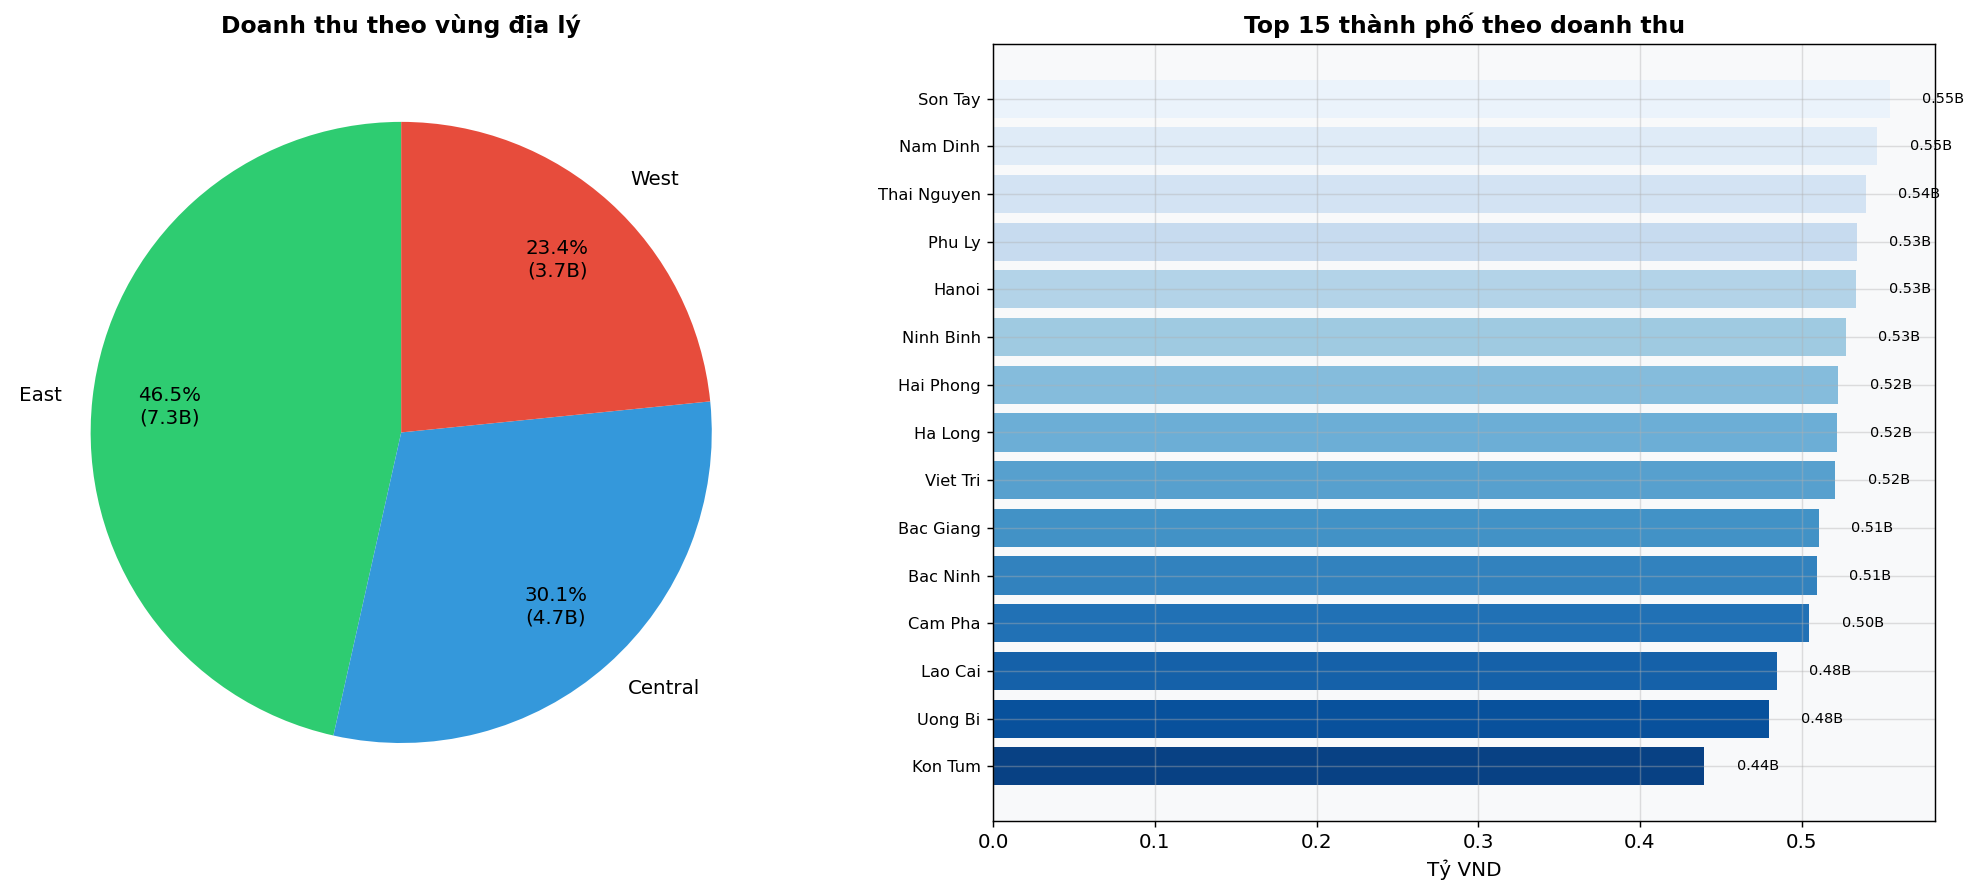

Region distribution: {'East': '7.29B', 'Central': '4.72B', 'West': '3.67B'}


In [7]:
oi_geo = order_items.copy()
oi_geo['line_rev'] = oi_geo['quantity'] * oi_geo['unit_price'] - oi_geo['discount_amount'].fillna(0)
oi_geo = oi_geo.merge(orders[['order_id', 'zip']], on='order_id', how='left')
oi_geo = oi_geo.merge(geography, on='zip', how='left')

# Revenue by region
region_rev = oi_geo.groupby('region')['line_rev'].sum().sort_values(ascending=False)
# Top 15 cities
city_rev = oi_geo.groupby('city')['line_rev'].sum().nlargest(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Region
colors_region = [C1, C2, C3]
wedges, texts, autotexts = axes[0].pie(
    region_rev.values, labels=region_rev.index,
    autopct=lambda p: f'{p:.1f}%\n({region_rev.sum()*p/100/1e9:.1f}B)',
    colors=colors_region, startangle=90, pctdistance=0.75
)
axes[0].set_title('Doanh thu theo vùng địa lý', fontweight='bold')

# Top cities
bars = axes[1].barh(range(len(city_rev)), city_rev.values/1e9,
                     color=sns.color_palette('Blues_r', len(city_rev)))
axes[1].set_yticks(range(len(city_rev)))
axes[1].set_yticklabels(city_rev.index, fontsize=9)
axes[1].set_title('Top 15 thành phố theo doanh thu', fontweight='bold')
axes[1].set_xlabel('Tỷ VND')
for bar in bars:
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                  f'{bar.get_width():.2f}B', va='center', fontsize=8)

plt.tight_layout()
save_fig(fig, 'D5_geography', cfg)
plt.show()

print(f"Region distribution: {dict(region_rev.map(lambda x: f'{x/1e9:.2f}B'))}")

## D6. Phân tích Returns & Reviews

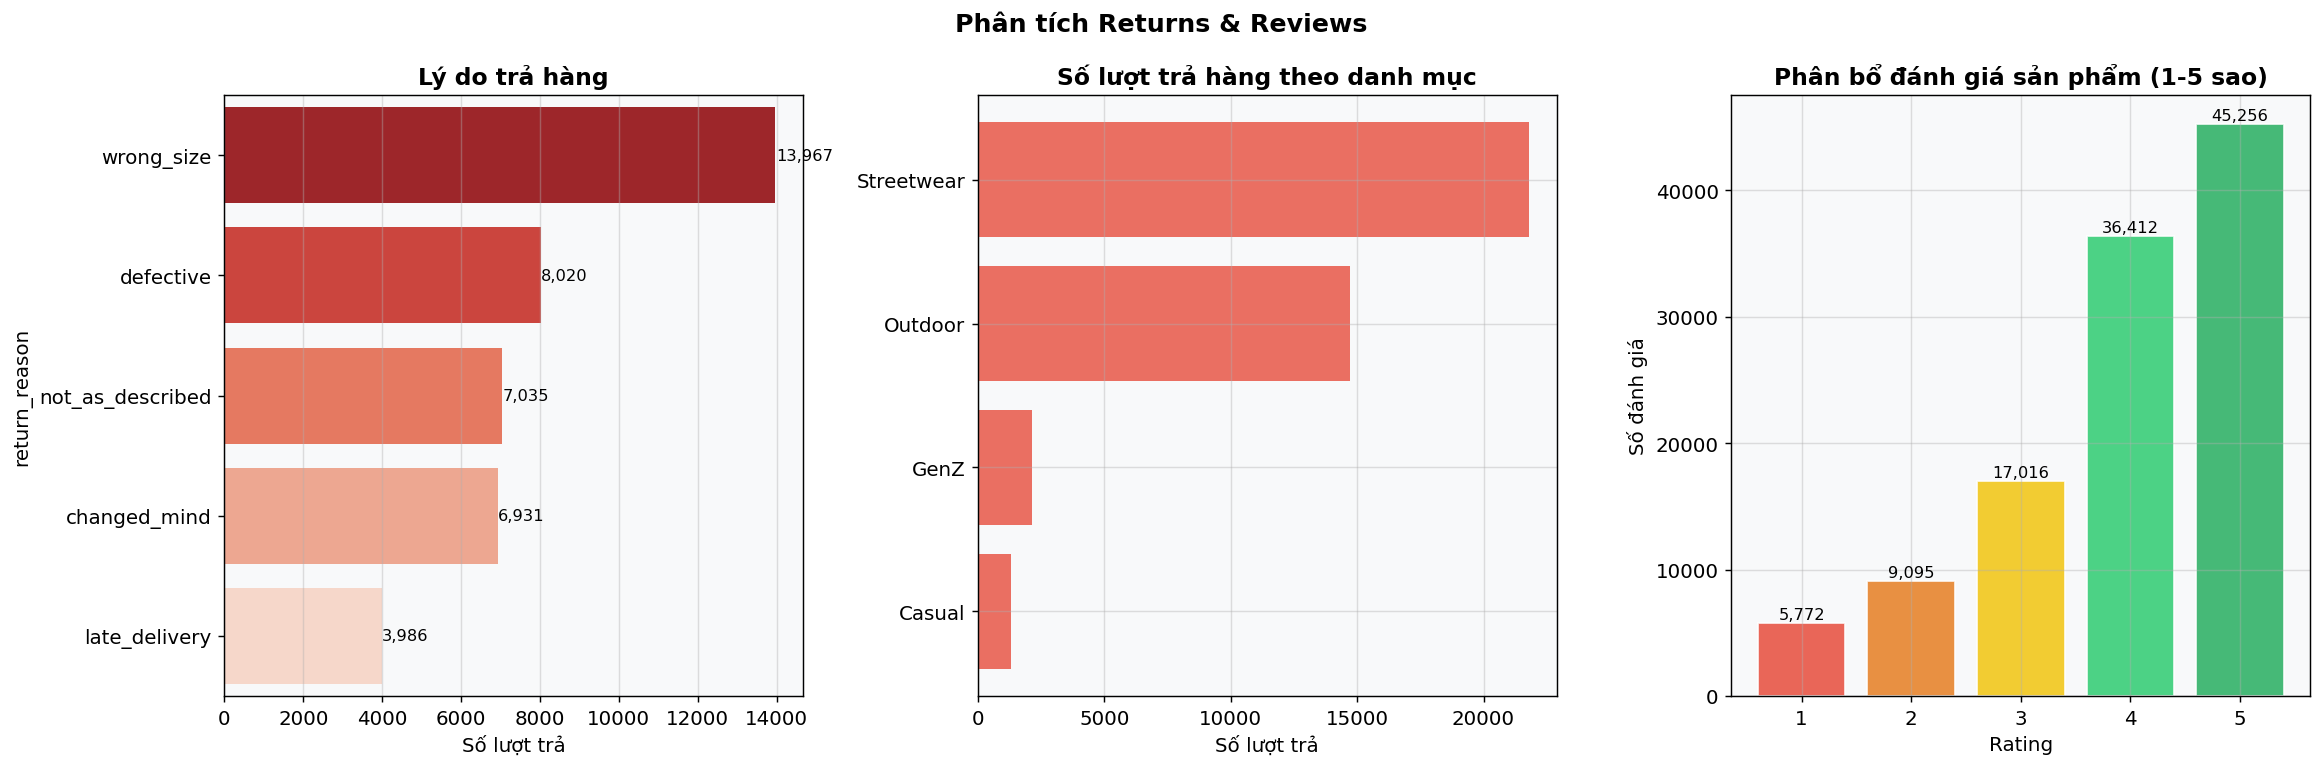

Tổng lượt trả: 39,939 (5.59% của order lines)
Rating trung bình: 3.94/5
Lý do trả nhiều nhất: wrong_size (13,967)


In [8]:
# Return analysis
ret_prod = returns.merge(products[['product_id', 'category', 'size']], on='product_id', how='left')

reason_counts = returns['return_reason'].value_counts()
cat_return    = ret_prod.groupby('category')['return_id'].count().sort_values(ascending=True)

# Review distribution
rating_dist = reviews['rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Return reasons
sns.barplot(x=reason_counts.values, y=reason_counts.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Lý do trả hàng', fontweight='bold')
axes[0].set_xlabel('Số lượt trả')
for i, v in enumerate(reason_counts.values):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

# Returns by category
axes[1].barh(cat_return.index, cat_return.values, color=C3, alpha=0.8)
axes[1].set_title('Số lượt trả hàng theo danh mục', fontweight='bold')
axes[1].set_xlabel('Số lượt trả')

# Rating distribution
colors_rating = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = axes[2].bar(rating_dist.index, rating_dist.values, color=colors_rating, alpha=0.85, edgecolor='white')
axes[2].set_title('Phân bổ đánh giá sản phẩm (1-5 sao)', fontweight='bold')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Số đánh giá')
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                  f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Phân tích Returns & Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'D6_returns_reviews', cfg)
plt.show()

avg_rating = reviews['rating'].mean()
return_rate = len(returns) / len(order_items) * 100
print(f"Tổng lượt trả: {len(returns):,} ({return_rate:.2f}% của order lines)")
print(f"Rating trung bình: {avg_rating:.2f}/5")
print(f"Lý do trả nhiều nhất: {reason_counts.idxmax()} ({reason_counts.max():,})")

## D7. Heatmap doanh thu theo tháng và ngày trong tuần (Seasonality cơ bản)

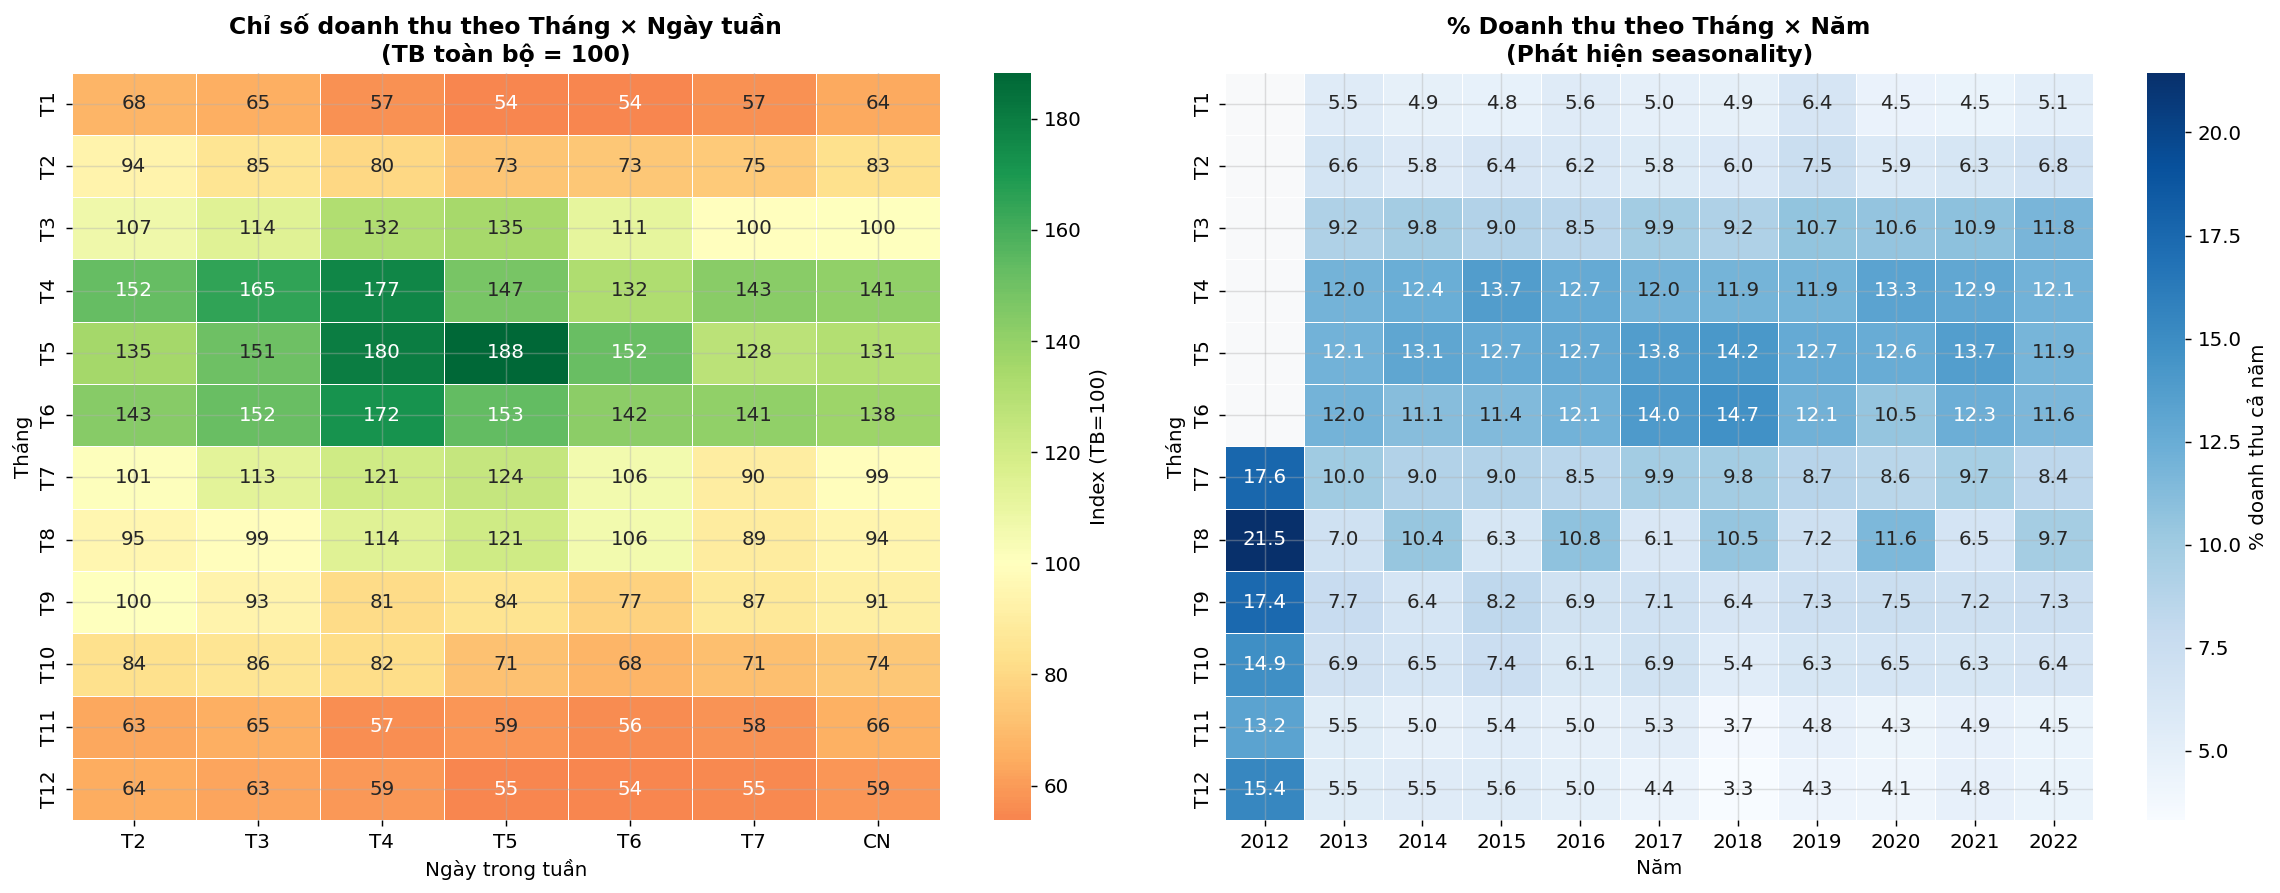

Tháng đỉnh doanh thu: T5 (12.95% revenue/năm)
Tháng thấp nhất: T1 (5.11% revenue/năm)


In [9]:
sales_heat = sales.copy()
sales_heat['Month'] = sales_heat['Date'].dt.month
sales_heat['DayOfWeek'] = sales_heat['Date'].dt.dayofweek  # 0=Mon
sales_heat['Year'] = sales_heat['Date'].dt.year

# Heatmap: Month x DayOfWeek (average revenue normalized by year mean)
pivot_md = sales_heat.pivot_table(values='Revenue', index='Month', columns='DayOfWeek', aggfunc='mean')
pivot_md.columns = ['T2','T3','T4','T5','T6','T7','CN']
pivot_md.index   = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

# Normalize
pivot_norm = pivot_md.div(pivot_md.mean().mean()) * 100

# Heatmap: Month x Year
pivot_my = sales_heat.pivot_table(values='Revenue', index='Month', columns='Year', aggfunc='sum')
pivot_my.index = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
pivot_my_norm = pivot_my.div(pivot_my.sum(axis=0)) * 100  # % of annual revenue

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pivot_norm, ax=axes[0], cmap='RdYlGn', center=100,
             annot=True, fmt='.0f', linewidths=0.5, cbar_kws={'label': 'Index (TB=100)'})
axes[0].set_title('Chỉ số doanh thu theo Tháng × Ngày tuần\n(TB toàn bộ = 100)', fontweight='bold')
axes[0].set_xlabel('Ngày trong tuần')
axes[0].set_ylabel('Tháng')

sns.heatmap(pivot_my_norm, ax=axes[1], cmap='Blues',
             annot=True, fmt='.1f', linewidths=0.5, cbar_kws={'label': '% doanh thu cả năm'})
axes[1].set_title('% Doanh thu theo Tháng × Năm\n(Phát hiện seasonality)', fontweight='bold')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Tháng')

plt.tight_layout()
save_fig(fig, 'D7_seasonality_heatmap', cfg)
plt.show()

# Insight
best_month = pivot_my_norm.mean(axis=1).idxmax()
worst_month = pivot_my_norm.mean(axis=1).idxmin()
print(f"Tháng đỉnh doanh thu: {best_month} ({pivot_my_norm.mean(axis=1).max():.2f}% revenue/năm)")
print(f"Tháng thấp nhất: {worst_month} ({pivot_my_norm.mean(axis=1).min():.2f}% revenue/năm)")

## D8. Web Traffic — Tổng quan lưu lượng truy cập

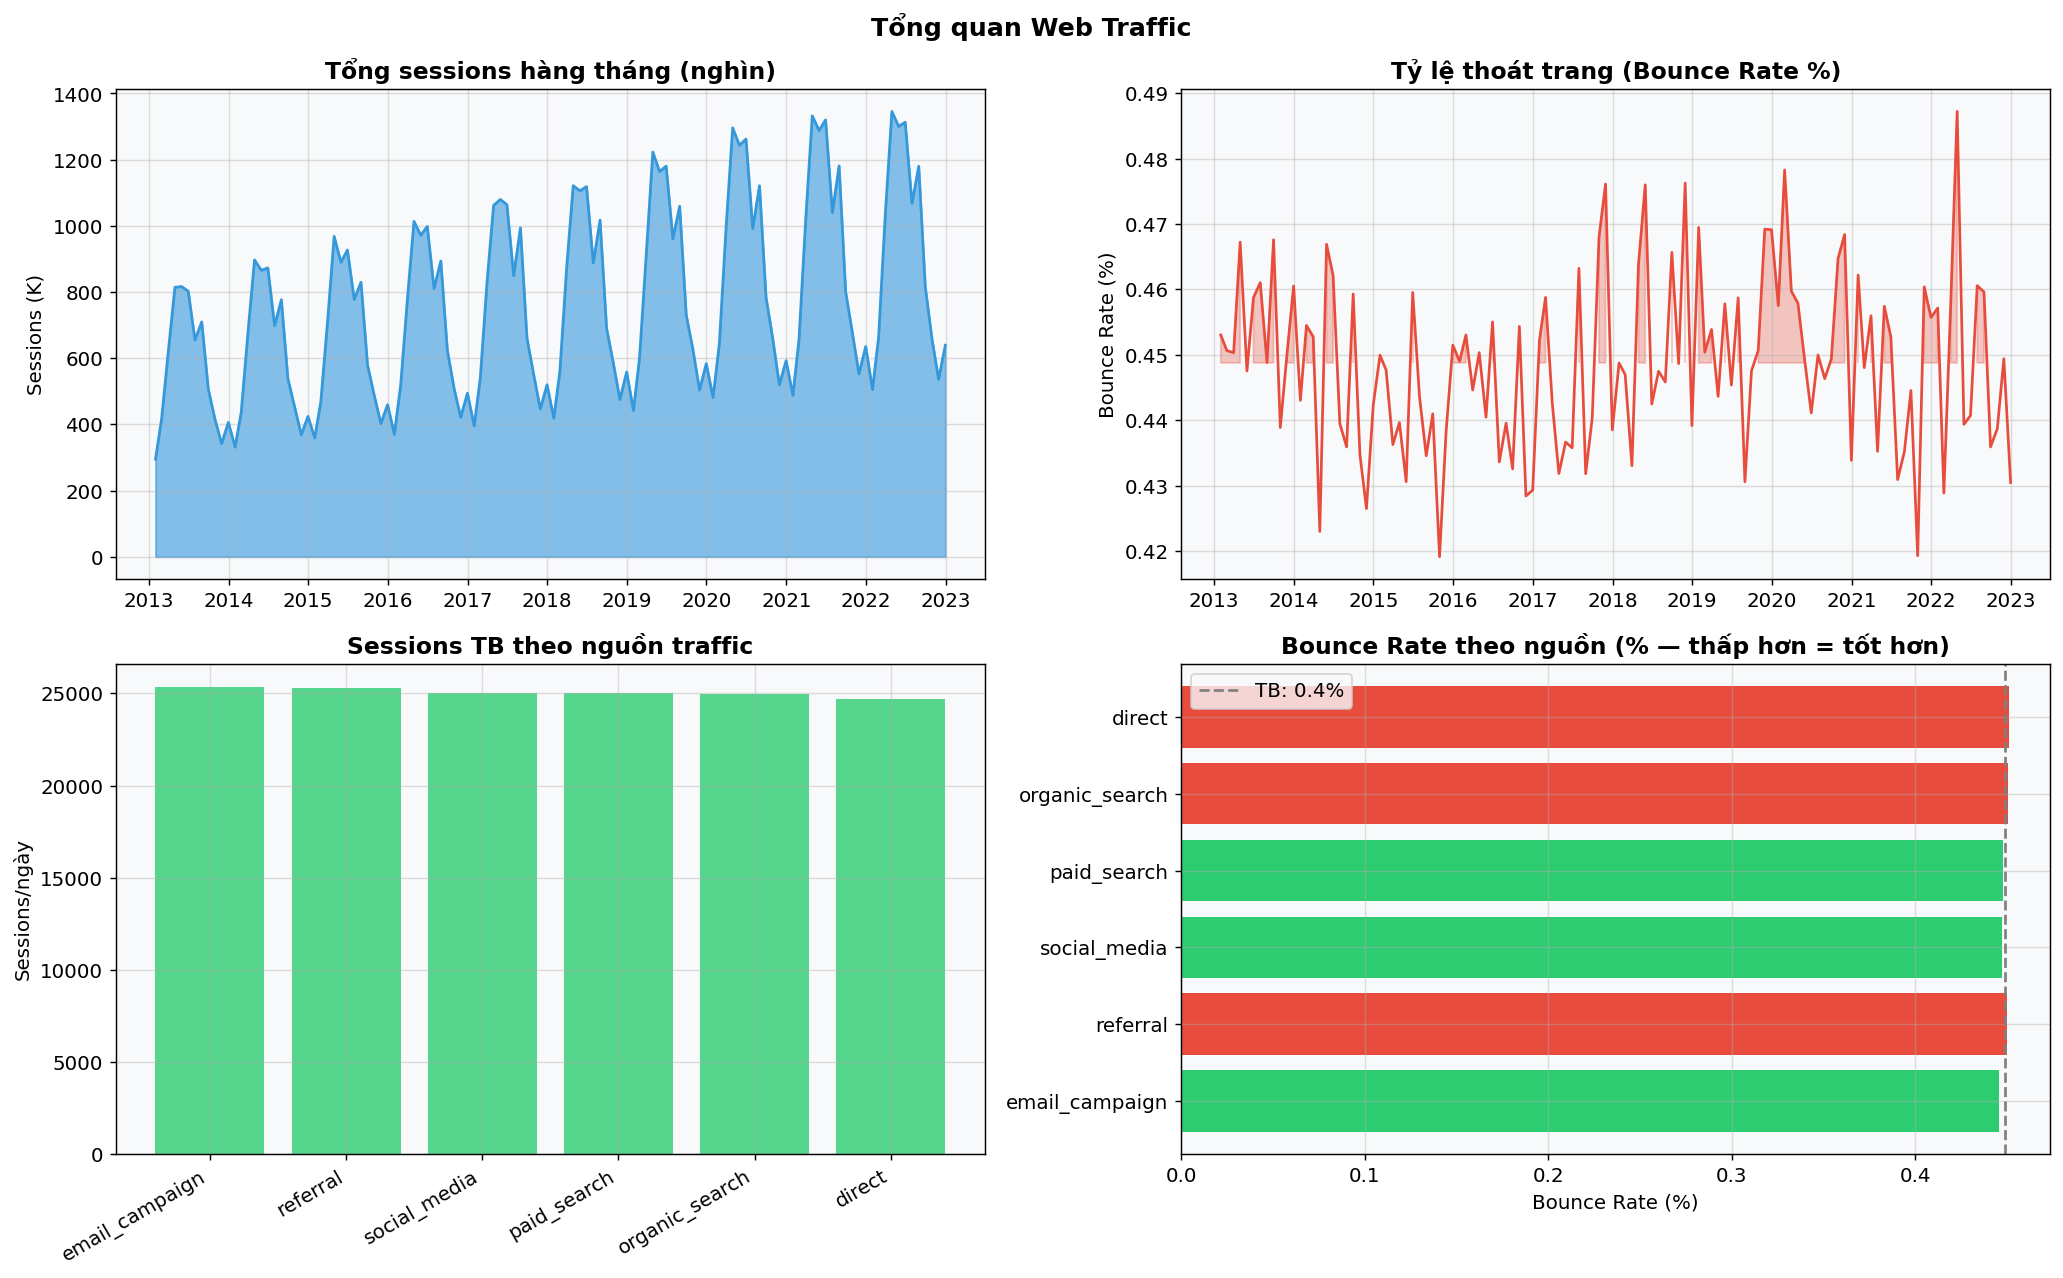

Tổng sessions: 91,452,537
Bounce rate TB: 0.45%
Nguồn sessions cao nhất: email_campaign


In [10]:
wt_monthly = web_traffic.resample('ME', on='date').agg(
    sessions=('sessions', 'sum'),
    visitors=('unique_visitors', 'sum'),
    pageviews=('page_views', 'sum'),
    bounce_rate=('bounce_rate', 'mean'),
).reset_index()

src_avg = web_traffic.groupby('traffic_source').agg(
    sessions=('sessions', 'mean'),
    bounce_rate=('bounce_rate', 'mean'),
    duration=('avg_session_duration_sec', 'mean'),
).reset_index().sort_values('sessions', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sessions trend
axes[0,0].fill_between(wt_monthly['date'], wt_monthly['sessions']/1e3, alpha=0.6, color=C2)
axes[0,0].plot(wt_monthly['date'], wt_monthly['sessions']/1e3, color=C2, linewidth=1.5)
axes[0,0].set_title('Tổng sessions hàng tháng (nghìn)', fontweight='bold')
axes[0,0].set_ylabel('Sessions (K)')

# Bounce rate trend
axes[0,1].plot(wt_monthly['date'], wt_monthly['bounce_rate']*100, color=C3, linewidth=1.5)
axes[0,1].fill_between(wt_monthly['date'], wt_monthly['bounce_rate']*100,
                        wt_monthly['bounce_rate'].mean()*100, alpha=0.3,
                        where=wt_monthly['bounce_rate'] > wt_monthly['bounce_rate'].mean(),
                        color=C3)
axes[0,1].set_title('Tỷ lệ thoát trang (Bounce Rate %)', fontweight='bold')
axes[0,1].set_ylabel('Bounce Rate (%)')

# Traffic source comparison
x = range(len(src_avg))
axes[1,0].bar(x, src_avg['sessions'], color=C1, alpha=0.8, label='Avg Sessions/day')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(src_avg['traffic_source'], rotation=30, ha='right')
axes[1,0].set_title('Sessions TB theo nguồn traffic', fontweight='bold')
axes[1,0].set_ylabel('Sessions/ngày')

# Bounce rate by source
axes[1,1].barh(src_avg['traffic_source'], src_avg['bounce_rate']*100,
                color=[C1 if v < src_avg['bounce_rate'].mean()*100 else C3
                       for v in src_avg['bounce_rate']*100])
axes[1,1].axvline(src_avg['bounce_rate'].mean()*100, color='gray',
                   linestyle='--', label=f"TB: {src_avg['bounce_rate'].mean()*100:.1f}%")
axes[1,1].set_title('Bounce Rate theo nguồn (% — thấp hơn = tốt hơn)', fontweight='bold')
axes[1,1].set_xlabel('Bounce Rate (%)')
axes[1,1].legend()

plt.suptitle('Tổng quan Web Traffic', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'D8_web_traffic', cfg)
plt.show()

print(f"Tổng sessions: {web_traffic['sessions'].sum():,.0f}")
print(f"Bounce rate TB: {web_traffic['bounce_rate'].mean()*100:.2f}%")
print(f"Nguồn sessions cao nhất: {src_avg.iloc[0]['traffic_source']}")

## Tổng kết Descriptive

| Chỉ số | Giá trị |
|--------|---------|
| Tổng Revenue 2012–2022 | Xem kết quả cell D1 |
| Gross Margin trung bình | ~X% |
| Tổng đơn hàng | N đơn |
| Delivered rate | ~X% |
| Tổng khách hàng | N |
| Rating trung bình | X/5 |
| Return rate | ~X% |

**Phát hiện chính:**
1. Doanh thu tăng trưởng nhất quán qua các năm với strong seasonality cuối năm
2. T11, T12 chiếm tỷ trọng cao nhất trong doanh thu năm (Black Friday, 11/11, 12/12, Giáng sinh)
3. Premium segment có gross margin cao nhất
4. Cuối tuần có chỉ số doanh thu thấp hơn ngày thường trong tuần
5. Email campaign có bounce rate thấp nhất — khách hàng chủ động hơn